In [6]:
import numpy as np
from utils.utils import read_raw_xrmc_data, print_image_summary, read_raw_xrmc_folder
from utils.plots import plot_image, plot_projection_mosaic

# Gerar Sino dos dados de projeção

## Carregar Flat Field Image

Flat Field Image Statistics:
 - Shape: (512, 512)
 - Min: 2.277e+04
 - Max: 2.400e+04
 - Mean: 2.374e+04
 - Std Dev: 1.560e+02
 - Type: float64


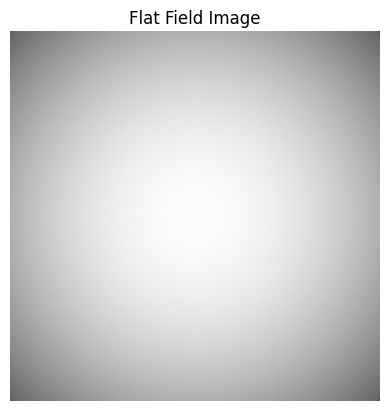

In [7]:
folder_name = '../output'
projs_params_dict = {
    'prefix': 'img_',
    'shape': (512, 512),
    'dtype': 'float64',
    'step': 1,
    'offset': 60,
    'slice_projection_range': (0, 360)
}


args_needed = {k: projs_params_dict[k] for k in ['shape', 'dtype', 'offset']}
flat = read_raw_xrmc_data(f'{folder_name}/flat.dat', **args_needed)

print_image_summary(flat, 'Flat Field Image')
plot_image(flat, title='Flat Field Image')

## Carregar projeções

Image Statistics:
 - Shape: (512, 512, 360)
 - Min: 4.248e+03
 - Max: 2.392e+04
 - Mean: 1.961e+04
 - Std Dev: 5.918e+03
 - Type: float64


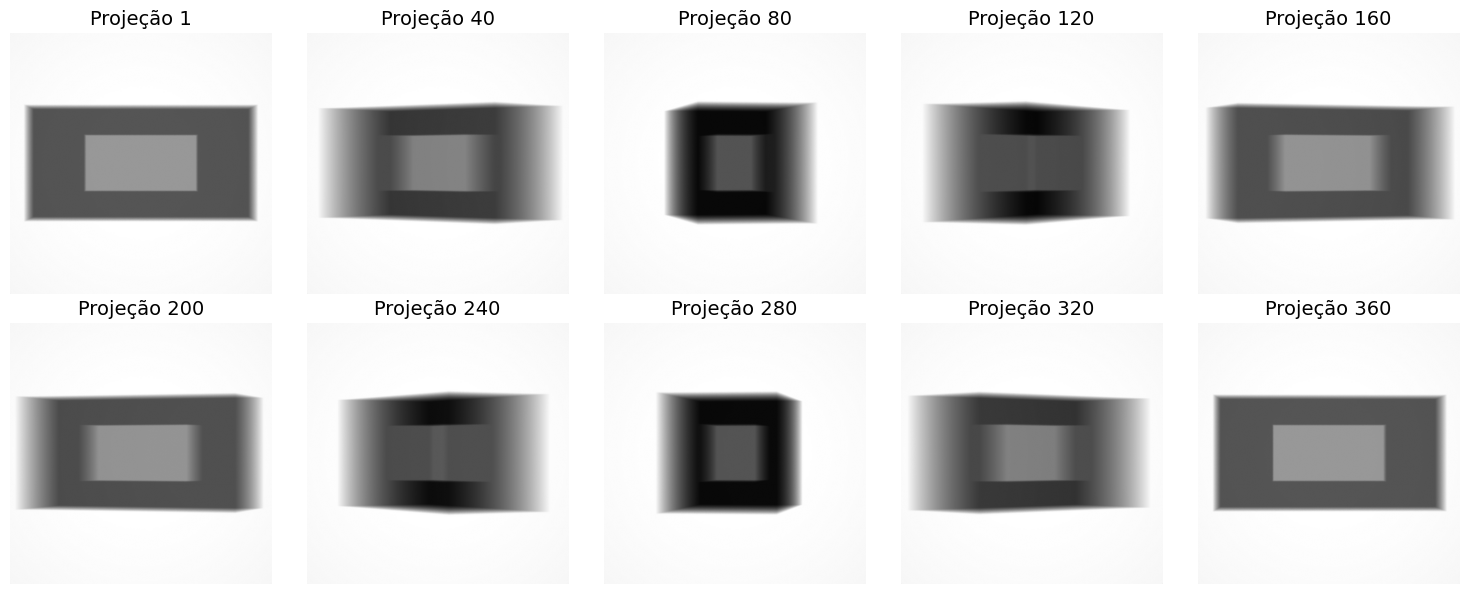

In [8]:
num_projections = 10
step_projections = 10

projections = read_raw_xrmc_folder(f'{folder_name}/raw', **projs_params_dict)
print_image_summary(projections)
plot_projection_mosaic(projections, num_projections=num_projections, fontsize=14)

## Aplicar correção Flat Field

Projections after Flat Field Correction Statistics:
 - Shape: (512, 512, 360)
 - Min: 1.775e-01
 - Max: 1.022e+00
 - Mean: 8.275e-01
 - Std Dev: 2.519e-01
 - Type: float64


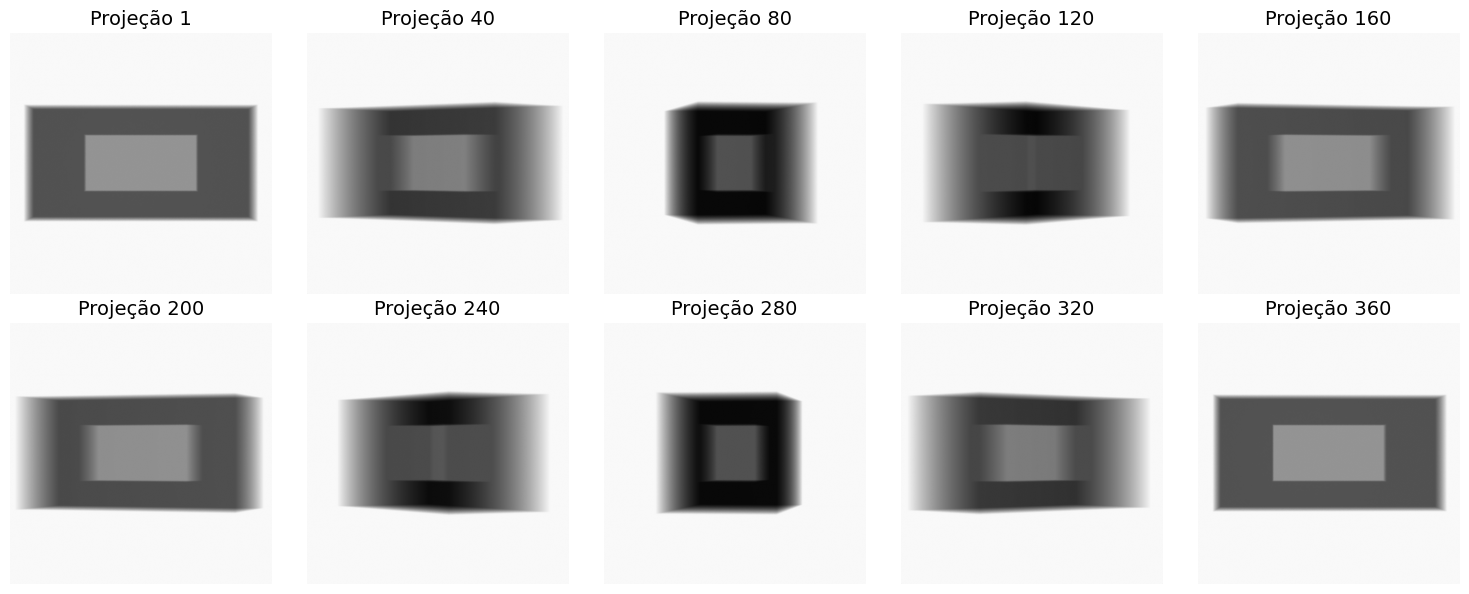

In [9]:
threshold = flat.max() * 0.01

for i in range(projections.shape[2]):
    projections[:,:,i] = np.divide(
        projections[:,:,i],
        flat,
        out=np.zeros_like(projections[:,:,i]),
        where=flat > threshold
    )
print_image_summary(projections, 'Projections after Flat Field Correction')
plot_projection_mosaic(projections, num_projections=num_projections, fontsize=14)

## Salvar dados processados

In [10]:
output_file = f'{folder_name}/sino.npz'
np.savez_compressed(output_file, sino=projections.astype('float32'))